In [36]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Dataset path
dataset_path = "/content/extracted_images/brain_tumor_dataset"

images = []
labels = []

# Load images
for category in ["yes", "no"]:
    folder = os.path.join(dataset_path, category)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)
        img = cv2.resize(img, (128, 128))

        images.append(img)

        if category == "yes":
            labels.append(1)
        else:
            labels.append(0)

X = np.array(images)
y = np.array(labels)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)
print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)
print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

Images Shape: (253, 128, 128, 3)
Labels Shape: (253,)
X_train Shape: (202, 128, 128, 3)
y_train Shape: (202,)
X_test Shape: (51, 128, 128, 3)
y_test Shape: (51,)


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [38]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,128,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5347 - loss: 63.4335 - val_accuracy: 0.5882 - val_loss: 6.4417
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 896ms/step - accuracy: 0.6634 - loss: 2.6403 - val_accuracy: 0.7255 - val_loss: 0.6454
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7970 - loss: 0.7353 - val_accuracy: 0.7451 - val_loss: 0.5009
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8218 - loss: 0.4281 - val_accuracy: 0.7647 - val_loss: 0.4628
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 938ms/step - accuracy: 0.8366 - loss: 0.3840 - val_accuracy: 0.8039 - val_loss: 0.4381
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8465 - loss: 0.3314 - val_accuracy: 0.8039 - val_loss: 0.4096
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 954ms/step - accuracy: 0.9059 - loss: 0.2635 - val_accuracy: 0.7647 - val_loss: 0.4530
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 917ms/step - accuracy: 0.9356 - loss: 0.1843 - val_accuracy: 0.8235 - val_loss: 0.4255


In [40]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - accuracy: 0.7843 - loss: 0.5796
Test Accuracy: 0.7843137383460999


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
No Tumor


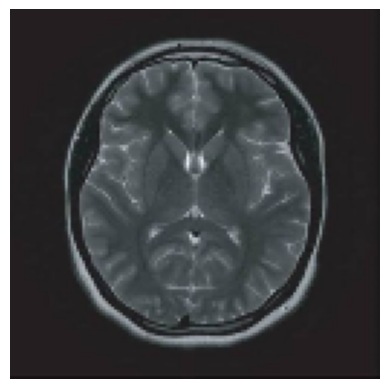

In [41]:
import cv2
import numpy as np

img_path = "/content/images (1).jfif"
img = cv2.imread(img_path)

if img is None:
    raise ValueError(f"Error: The image '{img_path}' was not found or could not be read. Please check the path or ensure the file exists.")

img = cv2.resize(img, (128,128))

img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

if prediction > 0.5:
    print("Tumor Detected")
else:
    print("No Tumor")

plt.imshow(cv2.cvtColor(img[0], cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
